# Opening Range Breakout (ORB) Strategy — Backtest Research

**Instrument:** QQQ (5-min bars from CSV)
**Signal:** Breakout of the opening range (configurable window: 5/10/15 min)
**Entry:** Basic (next bar open) or Advanced (breakout of opening range high/low)
**Stop loss:** Basic (opening range extreme), ATR-based, or combined
**Exit:** Stop loss, profit target (R-multiple), or EOD close
**Position sizing:** Risk-based with configurable leverage

This strategy has a large parameter space that is explored via grid search:
window size, leverage, profit target multiplier, stop loss type, ATR %,
threshold filter, and entry type.

## 1. Imports & Configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from itertools import product

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data — path to pre-saved 5-min CSV with columns:
#   timestamp, open, high, low, close, volume, trade_count, vwap
DATA_FILE = "QQQ_5min_Since_2016_v2_removingincomplete_days_2025-05-14.csv"
SYMBOL    = "QQQ"

# Account parameters
INITIAL_CAPITAL = 25_000
RISK_PERCENT    = 0.01   # 1% risk per trade

# Default strategy parameters (overridden during grid search)
DEFAULT_PARAMS = {
    "window_size":              5,       # minutes (5, 10, 15)
    "leverage_factor":          12,      # 1x, 3x, 4x, 12x
    "profit_target_multiplier": None,    # None = no target, or 5R, 10R, 15R
    "stop_loss_strategy":       "atr",   # "basic", "atr", "basic+atr"
    "atr_percent":              5,       # % of ATR for stop distance
    "threshold":                0.02,    # min opening range movement (% of open)
    "entry":                    "basic", # "basic" or "advanced"
}

## 2. Data Loading

Load pre-saved 5-min bars from CSV and convert timestamps to US/Eastern.

In [6]:
def load_data(filepath):
    """
    Load 5-min bar data from CSV.

    Expects columns: timestamp, open, high, low, close, volume.
    Returns DataFrame indexed by timestamp in US/Eastern timezone.
    """
    df = pd.read_csv(filepath, parse_dates=["timestamp"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["timestamp"] = df["timestamp"].dt.tz_convert("US/Eastern")
    df = df.set_index("timestamp").sort_index()
    print(f"Loaded {len(df):,} bars from {filepath}")
    print(f"Date range: {df.index.min()} → {df.index.max()}")
    return df


data = load_data(DATA_FILE)
data.head()

Loaded 181,740 bars from QQQ_5min_Since_2016_v2_removingincomplete_days_2025-05-14.csv
Date range: 2016-01-04 09:30:00-05:00 → 2025-05-13 15:55:00-04:00


,open,high,low,close,volume,trade_count,vwap,date
timestamp,,,,,,,,
2016-01-04 09:30:00-05:00,109.430,109.4500,109.05,109.1315,2227980,8117,109.260765,2016-01-04
2016-01-04 09:35:00-05:00,109.130,109.4200,109.12,109.3200,1724607,7567,109.288523,2016-01-04
2016-01-04 09:40:00-05:00,109.310,109.3400,108.92,108.9500,1463905,5840,109.121630,2016-01-04
2016-01-04 09:45:00-05:00,108.950,109.1100,108.83,109.0200,1115948,4793,108.943485,2016-01-04
2016-01-04 09:50:00-05:00,109.032,109.1361,109.02,109.0500,1039161,4504,109.068166,2016-01-04


## 3. Helper Functions

### 3a. Candle aggregation & threshold filter

In [7]:
def compute_candle(sub_candles):
    """Aggregate multiple bars into a single OHLC candle."""
    return (
        sub_candles.iloc[0]["open"],
        sub_candles["high"].max(),
        sub_candles["low"].min(),
        sub_candles.iloc[-1]["close"],
    )


def above_threshold(close_price, open_price, threshold_pct):
    """
    Check if the opening range movement exceeds the threshold.

    threshold_pct is in percentage points (e.g. 0.02 = 0.02% of open).
    """
    movement = abs(close_price - open_price)
    min_move = (threshold_pct / 100) * open_price
    return movement > min_move

### 3b. Entry functions

In [8]:
def basic_entry(day_data, first_candle, open_price, high_price, low_price, close_price):
    """
    Basic entry: determine direction from opening range, enter at next bar's open.

    Returns (signal, entry_time, entry_price, remaining_data) or all Nones.
    """
    if close_price > open_price:
        signal = "long"
    elif close_price < open_price:
        signal = "short"
    else:
        return None, None, None, None

    entry_time = first_candle.index[-1] + timedelta(minutes=5)
    if entry_time not in day_data.index:
        return None, None, None, None

    entry_price = day_data.loc[entry_time, "open"]
    remaining = day_data[day_data.index >= entry_time]
    return signal, entry_time, entry_price, remaining


def advanced_entry(day_data, first_candle, open_price, high_price, low_price, close_price):
    """
    Advanced entry: wait for price to break opening range high (long) or low (short).

    Returns (signal, entry_time, entry_price, remaining_data) or all Nones.
    """
    if close_price > open_price:
        signal, target_price = "long", high_price
    elif close_price < open_price:
        signal, target_price = "short", low_price
    else:
        return None, None, None, None

    next_time = first_candle.index[-1] + timedelta(minutes=5)
    next_data = day_data[day_data.index >= next_time]

    for idx, candle in next_data.iterrows():
        if signal == "long" and candle["high"] >= target_price:
            remaining = next_data[next_data.index >= idx + timedelta(minutes=5)]
            return signal, idx, target_price, remaining
        if signal == "short" and candle["low"] <= target_price:
            remaining = next_data[next_data.index >= idx + timedelta(minutes=5)]
            return signal, idx, target_price, remaining

    return None, None, None, None

### 3c. Stop loss & risk

In [9]:
def compute_stop_loss_basic(signal, high_price, low_price, entry_price):
    """Basic stop: opening range low (long) or high (short)."""
    if signal == "long":
        stop_loss = low_price
        risk = entry_price - stop_loss
    else:
        stop_loss = high_price
        risk = stop_loss - entry_price
    return stop_loss, risk


def compute_stop_loss_atr(atr_df, date, signal, entry_price, atr_percent):
    """ATR-based stop: entry ± (atr_percent/100) × ATR."""
    atr_val = atr_df.loc[date, "atr"]
    if atr_val is None or pd.isna(atr_val):
        return None, None

    distance = (atr_percent / 100) * atr_val
    if signal == "long":
        stop_loss = entry_price - distance
        risk = distance
    else:
        stop_loss = entry_price + distance
        risk = distance
    return stop_loss, risk


def compute_stop_loss_combined(atr_df, date, signal, entry_price, atr_percent, high_price, low_price):
    """Combined: basic stop adjusted by ATR."""
    atr_val = atr_df.loc[date, "atr"]
    if atr_val is None or pd.isna(atr_val):
        return None, None

    atr_offset = (atr_percent / 100) * atr_val
    if signal == "long":
        stop_loss = low_price - atr_offset
        risk = entry_price - stop_loss
    else:
        stop_loss = high_price + atr_offset
        risk = stop_loss - entry_price
    return stop_loss, risk

### 3d. Exit checks & profit target

In [10]:
def check_stop_loss(signal, stop_loss, candle):
    """Return exit price if stop loss hit, else None."""
    if signal == "long" and candle["low"] <= stop_loss:
        return stop_loss
    if signal == "short" and candle["high"] >= stop_loss:
        return stop_loss
    return None


def compute_target(profit_target_multiplier, signal, entry_price, risk):
    """Compute profit target price. Returns inf if no target."""
    if profit_target_multiplier is None:
        mult = np.inf
    else:
        mult = profit_target_multiplier

    if signal == "long":
        return entry_price + mult * risk
    else:
        return entry_price - mult * risk


def check_profit_target(signal, target, candle):
    """Return exit price if profit target hit, else None."""
    if target is None or np.isinf(target):
        return None
    if signal == "long" and candle["high"] >= target:
        return target
    if signal == "short" and candle["low"] <= target:
        return target
    return None

### 3e. ATR computation

In [11]:
def compute_atr_df(grouped_days):
    """
    Compute daily True Range and ATR-14 (Wilder's smoothing) from grouped daily data.

    Parameters
    ----------
    grouped_days : DataFrameGroupBy — data grouped by date.

    Returns
    -------
    pd.DataFrame indexed by date with columns 'tr' and 'atr'.
    """
    prev_close = None
    records = []

    for date, group in grouped_days:
        _, high_d, low_d, close_d = compute_candle(group)

        if prev_close is None:
            prev_close = close_d
            records.append({"date": date, "tr": np.nan, "atr": np.nan})
            continue

        tr = max(abs(high_d - low_d), abs(high_d - prev_close), abs(low_d - prev_close))
        records.append({"date": date, "tr": tr, "atr": np.nan})
        prev_close = close_d

    atr_df = pd.DataFrame(records).set_index("date")

    # Wilder's smoothing for ATR-14
    period = 14
    tr_vals = atr_df["tr"].dropna()
    if len(tr_vals) >= period:
        atr_df.loc[tr_vals.index[period - 1], "atr"] = tr_vals.iloc[:period].mean()
        for i in range(period, len(tr_vals)):
            prev_atr = atr_df["atr"].iloc[i]  # previous computed
            # Walk back to find last non-NaN atr
            idx = tr_vals.index[i]
            prev_idx = tr_vals.index[i - 1]
            prev_atr_val = atr_df.loc[prev_idx, "atr"]
            if pd.notna(prev_atr_val):
                atr_df.loc[idx, "atr"] = (prev_atr_val * (period - 1) + tr_vals.iloc[i]) / period

    return atr_df

## 4. Backtest Engine

`run_orb_backtest` is the core function. It takes all strategy parameters,
loops through each trading day, and returns a detailed audit DataFrame.

In [12]:
def run_orb_backtest(df, window_size, leverage_factor, profit_target_multiplier,
                     stop_loss_strategy, atr_percent, threshold, entry,
                     initial_capital=INITIAL_CAPITAL, risk_percent=RISK_PERCENT):
    """
    Run an Opening Range Breakout backtest.

    Parameters
    ----------
    df                       : pd.DataFrame — 5-min bars indexed by timestamp (US/Eastern).
    window_size              : int   — opening range window in minutes (5, 10, 15).
    leverage_factor          : float — max leverage multiplier.
    profit_target_multiplier : float or None — target as multiple of risk (e.g. 5 = 5R).
    stop_loss_strategy       : str   — 'basic', 'atr', or 'basic+atr'.
    atr_percent              : float — ATR multiplier for stop (as % of ATR).
    threshold                : float — min opening range movement (% of open price).
    entry                    : str   — 'basic' or 'advanced'.
    initial_capital          : float — starting account value.
    risk_percent             : float — fraction of capital risked per trade.

    Returns
    -------
    pd.DataFrame — one row per trade with full audit details.
    """
    account_value = initial_capital
    audit_data = []

    # Group by day
    df_copy = df.copy()
    df_copy["date"] = pd.to_datetime(df_copy.index.date)
    grouped = df_copy.groupby("date")

    # Pre-compute ATR if needed
    atr_df = None
    if stop_loss_strategy in ("atr", "basic+atr"):
        atr_df = compute_atr_df(grouped)

    n_bars = window_size // 5  # number of 5-min bars in opening range

    for date, group in grouped:
        day_data = group

        # --- Opening range ---
        first_candle = group.iloc[:n_bars]
        if len(first_candle) < n_bars:
            continue
        open_price, high_price, low_price, close_price = compute_candle(first_candle)

        # --- Threshold filter ---
        if not above_threshold(close_price, open_price, threshold):
            continue

        # --- Entry ---
        if entry == "basic":
            signal, entry_time, entry_price, remaining = basic_entry(
                day_data, first_candle, open_price, high_price, low_price, close_price)
        elif entry == "advanced":
            signal, entry_time, entry_price, remaining = advanced_entry(
                day_data, first_candle, open_price, high_price, low_price, close_price)
        else:
            continue

        if signal is None or entry_time is None:
            continue
        if remaining is None or len(remaining) == 0:
            continue

        # --- Stop loss & risk ---
        if stop_loss_strategy == "basic":
            stop_loss, risk = compute_stop_loss_basic(signal, high_price, low_price, entry_price)
        elif stop_loss_strategy == "atr":
            stop_loss, risk = compute_stop_loss_atr(atr_df, date, signal, entry_price, atr_percent)
        elif stop_loss_strategy == "basic+atr":
            stop_loss, risk = compute_stop_loss_combined(
                atr_df, date, signal, entry_price, atr_percent, high_price, low_price)
        else:
            continue

        if risk is None or risk <= 0:
            continue

        # --- Profit target ---
        target = compute_target(profit_target_multiplier, signal, entry_price, risk)

        # --- Walk through remaining bars ---
        exit_price = None
        exit_time = None
        exit_condition = None
        sl_hit = False
        pt_hit = False

        for idx, candle in remaining.iterrows():
            # Check stop loss first
            sl_price = check_stop_loss(signal, stop_loss, candle)
            if sl_price is not None:
                exit_price, exit_time, exit_condition = sl_price, idx, "Stop Loss"
                sl_hit = True
                break

            # Check profit target
            pt_price = check_profit_target(signal, target, candle)
            if pt_price is not None:
                exit_price, exit_time, exit_condition = pt_price, idx, "Profit Target"
                pt_hit = True
                break

        # EOD exit
        if exit_price is None:
            exit_price = remaining["close"].iloc[-1]
            exit_time = remaining.index[-1]
            exit_condition = "EOD"

        # --- P&L ---
        if signal == "long":
            profit_per_share = exit_price - entry_price
        else:
            profit_per_share = entry_price - exit_price

        # Position sizing
        shares_by_risk = (account_value * risk_percent) / risk
        shares_by_lev  = (account_value * leverage_factor) / entry_price
        shares = int(min(shares_by_risk, shares_by_lev))

        dollar_profit = shares * profit_per_share
        pct_return = dollar_profit * 100 / account_value if account_value > 0 else 0
        account_value += dollar_profit

        audit_data.append({
            "date": date,
            "first_window_open": open_price,
            "first_window_high": high_price,
            "first_window_low": low_price,
            "first_window_close": close_price,
            "position": signal,
            "entry_price": round(entry_price, 4),
            "Risk": round(risk, 4),
            "Profit_Target": round(target, 4) if not np.isinf(target) else None,
            "percentage_return": round(pct_return, 4),
            "result_dollars_1share": round(profit_per_share, 4),
            "result_in_R": round(profit_per_share / risk, 4),
            "firstTermSharesCalc": round(shares_by_risk, 0),
            "secondTermSharesCalc": round(shares_by_lev, 0),
            "final_Shares": shares,
            "dollar_profit": round(dollar_profit, 2),
            "stop_loss_hit": "Yes" if sl_hit else "No",
            "profit_target_hit": "Yes" if pt_hit else "No",
            "entry_time": entry_time,
            "exit_time": exit_time + timedelta(minutes=5),
            "exit_price": round(exit_price, 4),
            "exit_condition": exit_condition,
            "daily_result": "Win" if profit_per_share > 0 else "Loss",
            "account_value_end": round(account_value, 2),
        })

    if not audit_data:
        return pd.DataFrame()

    audit_df = pd.DataFrame(audit_data)
    audit_df = audit_df[[
        "date", "first_window_open", "first_window_high", "first_window_low", "first_window_close",
        "position", "entry_price", "Risk", "Profit_Target", "percentage_return",
        "result_dollars_1share", "result_in_R", "firstTermSharesCalc", "secondTermSharesCalc",
        "final_Shares", "dollar_profit", "stop_loss_hit", "profit_target_hit", "exit_time",
        "entry_time", "exit_price", "exit_condition", "daily_result", "account_value_end",
    ]]
    return audit_df

## 5. Performance Metrics

In [13]:
def analyze_drawdowns(audit):
    """Compute max consecutive losses, max drawdown, and avg drawdown duration."""
    i = 0
    max_consec = 0
    max_dd = 0
    durations = []

    for j in range(1, len(audit)):
        if audit.loc[j, "percentage_return"] < 0:
            if i == 0:
                init_cash = audit.loc[j, "account_value_end"] - audit.loc[j, "dollar_profit"]
            i += 1
        elif i > 0:
            end_cash = audit.loc[j - 1, "account_value_end"]
            max_consec = max(max_consec, i)
            dd = (end_cash - init_cash) / init_cash
            max_dd = min(dd, max_dd)
            durations.append(i)
            i = 0

    # Handle trailing drawdown
    if i > 0:
        end_cash = audit.loc[len(audit) - 1, "account_value_end"]
        max_consec = max(max_consec, i)
        dd = (end_cash - init_cash) / init_cash
        max_dd = min(dd, max_dd)
        durations.append(i)

    avg_dur = sum(durations) / len(durations) if durations else 0
    return max_consec, max_dd, avg_dur


def evaluate_audit(audit, start_date=None, end_date=None):
    """
    Compute comprehensive performance metrics from a backtest audit.

    Returns a dict with Sharpe, Sortino, Calmar, drawdown stats, win/loss
    breakdown, and yearly/quarterly/monthly return tables.
    """
    df = audit.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["entry_time"] = pd.to_datetime(df["entry_time"])
    df["exit_time"] = pd.to_datetime(df["exit_time"])

    if start_date:
        df = df[df["date"] >= pd.to_datetime(start_date)]
    if end_date:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.sort_values("date").reset_index(drop=True)

    if len(df) == 0:
        return {}

    # Daily returns
    df["daily_return"] = df["dollar_profit"] / df["account_value_end"].shift(1)
    df["daily_return"] = df["daily_return"].fillna(0)

    cumulative_return = (1 + df["daily_return"]).prod() - 1
    annualized_return = (1 + cumulative_return) ** (252 / len(df)) - 1
    volatility = df["daily_return"].std() * np.sqrt(252)

    sharpe = df["daily_return"].mean() / df["daily_return"].std() * np.sqrt(252) if df["daily_return"].std() > 0 else 0

    downside_std = df[df["daily_return"] < 0]["daily_return"].std()
    sortino = df["daily_return"].mean() / downside_std * np.sqrt(252) if downside_std > 0 else np.nan

    # Win/loss
    wins   = df["dollar_profit"] > 0
    losses = df["dollar_profit"] < 0
    total_win  = df.loc[wins, "dollar_profit"].sum()
    total_loss = abs(df.loc[losses, "dollar_profit"].sum())
    pct_wins = wins.sum() / (wins.sum() + losses.sum()) if (wins.sum() + losses.sum()) > 0 else np.nan
    avg_win  = df.loc[wins, "daily_return"].mean() * 100 if wins.any() else 0
    avg_loss = df.loc[losses, "daily_return"].mean() * 100 if losses.any() else 0
    profit_factor = total_win / total_loss if total_loss > 0 else np.nan

    # Consecutive streaks
    df["win_group"]  = (~wins).cumsum()
    df["loss_group"] = (~losses).cumsum()
    max_consec_gains  = int(wins.groupby(df["win_group"]).sum().max()) if wins.any() else 0
    max_consec_losses_streak = int(losses.groupby(df["loss_group"]).sum().max()) if losses.any() else 0

    # Drawdowns
    max_consec_dd, max_dd, avg_dd_dur = analyze_drawdowns(audit)

    # Calmar
    calmar = annualized_return / abs(max_dd) if max_dd != 0 else np.nan

    # Trade duration
    df["trade_duration_hrs"] = (df["exit_time"] - df["entry_time"]).dt.total_seconds() / 3600

    # Periodic returns
    df["year"] = df["date"].dt.year
    yearly = df.groupby("year")["daily_return"].apply(lambda x: (1 + x).prod() - 1)
    trades_per_year = int(df.groupby("year").size().mean())

    df["quarter"] = df["date"].dt.to_period("Q")
    quarterly = df.groupby("quarter")["daily_return"].apply(lambda x: (1 + x).prod() - 1)

    df["month"] = df["date"].dt.to_period("M")
    monthly = df.groupby("month")["daily_return"].apply(lambda x: (1 + x).prod() - 1)

    return {
        "Backtest Start":         str(df["date"].min().date()),
        "Backtest End":           str(df["date"].max().date()),
        "Initial Balance":        audit["account_value_end"].iloc[0] - audit["dollar_profit"].iloc[0],
        "Final Balance":          round(audit["account_value_end"].iloc[-1], 2),
        "Sharpe Ratio":           round(sharpe, 2),
        "Sortino Ratio":          round(sortino, 2),
        "Calmar Ratio":           round(calmar, 2),
        "Cumulative Return":      f"{cumulative_return * 100:.2f}%",
        "Annualized Return":      f"{annualized_return * 100:.2f}%",
        "Volatility (Ann.)":      f"{volatility * 100:.2f}%",
        "Max Drawdown":           f"{max_dd * 100:.2f}%",
        "Avg DD Duration (days)": round(avg_dd_dur, 2),
        "Avg Trade Duration (h)": round(df["trade_duration_hrs"].mean(), 2),
        "Max Consec Gains":       max_consec_gains,
        "Max Consec Losses":      max_consec_losses_streak,
        "Win Rate":               f"{pct_wins * 100:.2f}%",
        "Avg Win (%)":            f"{avg_win:.2f}%",
        "Avg Loss (%)":           f"{avg_loss:.2f}%",
        "Profit Factor":          round(profit_factor, 2),
        "Trades / Year":          trades_per_year,
        "Yearly Returns":         {int(y): f"{r*100:.2f}%" for y, r in yearly.items()},
        "Quarterly Returns":      {str(q): f"{r*100:.2f}%" for q, r in quarterly.items()},
        "Monthly Returns":        {str(m): f"{r*100:.2f}%" for m, r in monthly.items()},
        "Avg Monthly Return":     f"{monthly.mean()*100:.2f}%",
        "Median Monthly Return":  f"{monthly.median()*100:.2f}%",
    }

## 6. Run Default Backtest

In [14]:
audit = run_orb_backtest(data, **DEFAULT_PARAMS)

print(f"Total trades: {len(audit)}")
audit.head()

Total trades: 2109


,date,first_window_open,first_window_high,first_window_low,first_window_close,position,entry_price,Risk,Profit_Target,percentage_return,result_dollars_1share,result_in_R,firstTermSharesCalc,secondTermSharesCalc,final_Shares,dollar_profit,stop_loss_hit,profit_target_hit,exit_time,entry_time,exit_price,exit_condition,daily_result,account_value_end
0,2016-01-26,102.64,102.75,102.397,102.7000,long,102.694,0.1429,None,-0.9997,-0.1429,-1.0000,1749.0,2921.0,1749,-249.93,Yes,No,2016-01-26 09:40:00-05:00,2016-01-26 09:35:00-05:00,102.5511,Stop Loss,Loss,24750.07
1,2016-01-28,102.19,102.29,102.000,102.1599,short,102.140,0.1405,None,1.2096,0.1700,1.2101,1762.0,2908.0,1761,299.37,No,No,2016-01-28 16:00:00-05:00,2016-01-28 09:35:00-05:00,101.9700,EOD,Win,25049.44
2,2016-01-29,102.02,102.14,101.940,102.0595,long,102.060,0.1384,None,14.8767,2.0600,14.8833,1810.0,2945.0,1809,3726.54,No,No,2016-01-29 16:00:00-05:00,2016-01-29 09:35:00-05:00,104.1200,EOD,Win,28775.98
3,2016-02-01,103.62,103.68,103.440,103.4400,short,103.440,0.1341,None,-0.9998,-0.1341,-1.0000,2145.0,3338.0,2145,-287.71,Yes,No,2016-02-01 09:40:00-05:00,2016-02-01 09:35:00-05:00,103.5741,Stop Loss,Loss,28488.27
4,2016-02-03,102.80,102.83,102.600,102.6067,short,102.610,0.1406,None,6.6817,0.9400,6.6846,2026.0,3332.0,2025,1903.50,No,No,2016-02-03 16:00:00-05:00,2016-02-03 09:35:00-05:00,101.6700,EOD,Win,30391.77


In [15]:
# Performance metrics
results = evaluate_audit(audit)
for k, v in results.items():
    if isinstance(v, dict):
        print(f"\n{k}:")
        for sub_k, sub_v in v.items():
            print(f"  {sub_k}: {sub_v}")
    else:
        print(f"{k}: {v}")

Backtest Start: 2016-01-26
Backtest End: 2025-05-13
Initial Balance: 25000.0
Final Balance: 27803591.11
Sharpe Ratio: 1.6
Sortino Ratio: 35.34
Calmar Ratio: 4.16
Cumulative Return: 112237.41%
Annualized Return: 131.47%
Volatility (Ann.): 64.23%
Max Drawdown: -31.62%
Avg DD Duration (days): 8.73
Avg Trade Duration (h): 1.07
Max Consec Gains: 3
Max Consec Losses: 38
Win Rate: 11.33%
Avg Win (%): 10.11%
Avg Loss (%): -0.83%
Profit Factor: 1.19
Trades / Year: 210

Yearly Returns:
  2016: 328.34%
  2017: 17.26%
  2018: 332.71%
  2019: 197.43%
  2020: 106.24%
  2021: 215.85%
  2022: 17.21%
  2023: 124.32%
  2024: -7.44%
  2025: 9.62%

Quarterly Returns:
  2016Q1: 54.19%
  2016Q2: 37.10%
  2016Q3: 26.32%
  2016Q4: 60.41%
  2017Q1: -1.36%
  2017Q2: -12.39%
  2017Q3: 17.33%
  2017Q4: 15.65%
  2018Q1: -17.28%
  2018Q2: 64.44%
  2018Q3: 135.14%
  2018Q4: 35.29%
  2019Q1: 38.35%
  2019Q2: 6.66%
  2019Q3: 64.98%
  2019Q4: 22.17%
  2020Q1: 9.84%
  2020Q2: 130.42%
  2020Q3: -11.71%
  2020Q4: -7.70%
 

## 7. Equity Curve

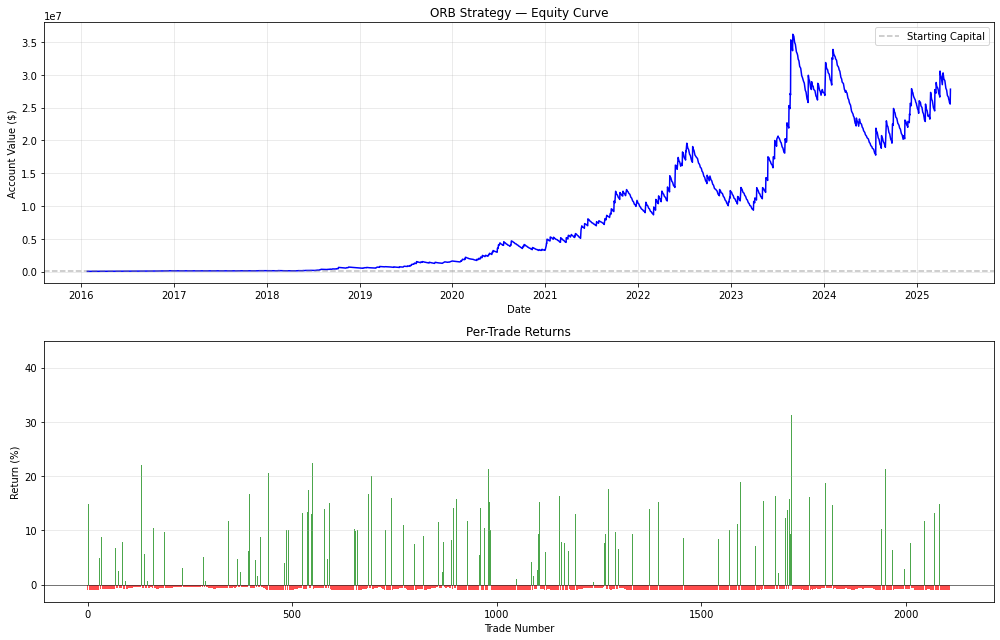

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Capital curve
ax = axes[0]
dates = pd.to_datetime(audit["date"])
ax.plot(dates.values, audit["account_value_end"].values, color="blue", linewidth=1.5)
ax.axhline(y=INITIAL_CAPITAL, color="gray", linestyle="--", alpha=0.5, label="Starting Capital")
ax.set_xlabel("Date")
ax.set_ylabel("Account Value ($)")
ax.set_title("ORB Strategy — Equity Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# Per-trade returns
ax = axes[1]
colors = ["green" if x > 0 else "red" for x in audit["percentage_return"]]
ax.bar(range(len(audit)), audit["percentage_return"], color=colors, alpha=0.7, width=1.0)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xlabel("Trade Number")
ax.set_ylabel("Return (%)")
ax.set_title("Per-Trade Returns")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 8. Long vs Short Breakdown

In [17]:
for side in ["long", "short"]:
    subset = audit[audit["position"] == side]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["dollar_profit"] > 0).sum()
    net = subset["dollar_profit"].sum()
    wr = wins / n * 100

    print(f"\n{side.upper()}: {n} trades, WR={wr:.1f}%, Net PnL=${net:,.0f}")

    for reason in ["Stop Loss", "Profit Target", "EOD"]:
        r = subset[subset["exit_condition"] == reason]
        if r.empty:
            continue
        print(f"  {reason:<14} — {len(r):3d} trades, avg return: {r['percentage_return'].mean():+.2f}%")


LONG: 1098 trades, WR=11.7%, Net PnL=$12,098,822
  Stop Loss      — 970 trades, avg return: -0.83%
  EOD            — 128 trades, avg return: +9.87%

SHORT: 1011 trades, WR=11.0%, Net PnL=$15,679,769
  Stop Loss      — 900 trades, avg return: -0.83%
  EOD            — 111 trades, avg return: +10.40%


## 9. Parameter Grid Search

Explore the full parameter space. Each combination runs the backtest
and collects summary metrics for comparison.

In [18]:
# Define parameter grid
param_grid = {
    "window_size":              [5, 10, 15],
    "leverage_factor":          [12],
    "profit_target_multiplier": [None],
    "stop_loss_strategy":       ["basic", "atr"],
    "atr_percent":              [2, 5, 10],
    "threshold":                [0, 0.02],
    "entry":                    ["basic"],
}

# Parameter names in order
param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))

print(f"Total parameter combinations: {len(all_combos)}")

grid_results = []
failed = []

for i, combo in enumerate(all_combos):
    params = dict(zip(param_keys, combo))

    # Skip ATR params when using basic stop loss
    if params["stop_loss_strategy"] == "basic" and params["atr_percent"] != param_grid["atr_percent"][0]:
        continue

    try:
        audit_run = run_orb_backtest(data, **params)
        if audit_run.empty:
            continue
        score = evaluate_audit(audit_run)
        if not score:
            continue

        entry = {**params, **{k: v for k, v in score.items()
                              if k not in ("Yearly Returns", "Quarterly Returns", "Monthly Returns")}}
        grid_results.append(entry)

    except Exception as e:
        failed.append((params, str(e)))

print(f"\nCompleted: {len(grid_results)} | Failed: {len(failed)}")

grid_df = pd.DataFrame(grid_results)

Total parameter combinations: 36

Completed: 24 | Failed: 0


In [19]:
# Sort by Sortino Ratio and display top results
if not grid_df.empty:
    top = grid_df.sort_values("Sortino Ratio", ascending=False).head(15)

    display_cols = ["window_size", "stop_loss_strategy", "atr_percent", "threshold",
                    "Sharpe Ratio", "Sortino Ratio", "Calmar Ratio", "Cumulative Return",
                    "Max Drawdown", "Win Rate", "Profit Factor", "Trades / Year"]
    available = [c for c in display_cols if c in top.columns]

    print("TOP PARAMETER COMBINATIONS (by Sortino):")
    print("=" * 120)
    print(top[available].to_string(index=False))
else:
    print("No results — check data file path.")

TOP PARAMETER COMBINATIONS (by Sortino):
 window_size stop_loss_strategy  atr_percent  threshold  Sharpe Ratio  Sortino Ratio  Calmar Ratio Cumulative Return Max Drawdown Win Rate  Profit Factor  Trades / Year
           5                atr           10       0.02          1.38          79.29          2.82         10914.88%      -26.76%   18.73%           1.29            210
           5                atr           10       0.00          1.22          64.40          2.25          7719.85%      -27.23%   18.45%           1.29            229
          10                atr           10       0.00          1.09          62.94          1.75          4128.87%      -28.94%   18.00%           1.23            230
          10                atr           10       0.02          1.09          62.05          1.88          3258.41%      -26.77%   17.89%           1.23            216
          15                atr           10       0.02          0.95          52.18          1.42          1577.9

## 10. Conclusion

The ORB strategy on QQQ shows meaningful edge with the right parameter combination.
ATR-based stops with 12x leverage and small threshold filter tend to produce the
best risk-adjusted returns (high Sortino). The grid search above identifies optimal
configurations.

**Key findings from parameter sweep:**
- ATR-based stops generally outperform basic (opening-range) stops
- A small threshold filter (0.02%) improves quality by filtering out noise days
- Profit targets (R-multiples) can be explored but often reduce total P&L vs. EOD exit
- Advanced entry (breakout confirmation) reduces trade count but may improve win rate